In [1]:
!python --version

Python 3.10.0


In [2]:
%pip install openseespy
%pip install numpy
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Vishal\Downloads\Opensees\.myenv\Scripts\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\Vishal\Downloads\Opensees\.myenv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Vishal\Downloads\Opensees\.myenv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Vishal\Downloads\Opensees\.myenv\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
from matplotlib import image as img
from matplotlib import pyplot as plt

In [4]:
image = img.imread("image.png")

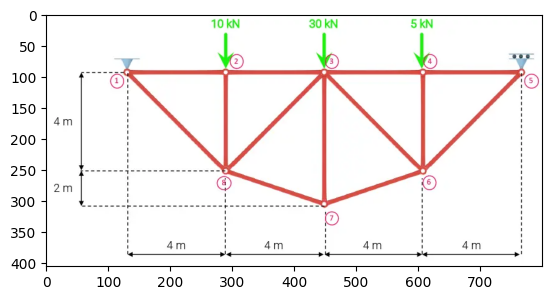

In [5]:
plt.imshow(image)

In [6]:
import numpy as np
import pandas as pd 

In [7]:
nodes = np.array([[0,6],
                  [4,6],
                  [8,6],
                  [12,6],
                  [16,6],
                  [12,2],
                  [8,0],
                  [4,2]])
elements = np.array([[1,2],
                     [2,3],
                     [3,4],
                     [4,5],
                     [5,6],
                     [6,7],
                     [7,8],
                     [1,8],
                     [2,8],
                     [3,8],
                     [3,7],
                     [3,6],
                     [4,6]])

In [8]:
for e in elements:
    ni = e[0]
    nj = e[1]
    xi = nodes[ni-1][0]
    yi = nodes[ni-1][1]
    xj = nodes[nj-1][0]
    yj = nodes[nj-1][1]
    print("Node ",ni," ",xi," ",yi,"Node ",nj," ",xj," ",yj)

Node  1   0   6 Node  2   4   6
Node  2   4   6 Node  3   8   6
Node  3   8   6 Node  4   12   6
Node  4   12   6 Node  5   16   6
Node  5   16   6 Node  6   12   2
Node  6   12   2 Node  7   8   0
Node  7   8   0 Node  8   4   2
Node  1   0   6 Node  8   4   2
Node  2   4   6 Node  8   4   2
Node  3   8   6 Node  8   4   2
Node  3   8   6 Node  7   8   0
Node  3   8   6 Node  6   12   2
Node  4   12   6 Node  6   12   2


Node  1   0   6 Node  2   4   6
Node  2   4   6 Node  3   8   6
Node  3   8   6 Node  4   12   6
Node  4   12   6 Node  5   16   6
Node  5   16   6 Node  6   12   2
Node  6   12   2 Node  7   8   0
Node  7   8   0 Node  8   4   2
Node  1   0   6 Node  8   4   2
Node  2   4   6 Node  8   4   2
Node  3   8   6 Node  8   4   2
Node  3   8   6 Node  7   8   0
Node  3   8   6 Node  6   12   2
Node  4   12   6 Node  6   12   2


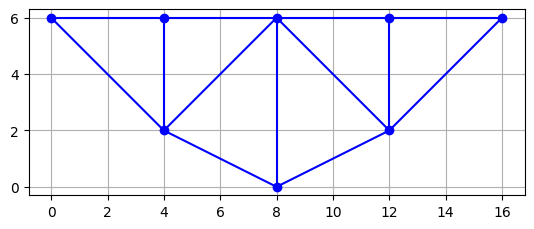

In [9]:
fig = plt.figure()
fig.gca().set_aspect("equal",adjustable="box")
for e in elements:
    ni = e[0]
    nj = e[1]
    xi = nodes[ni-1][0]
    yi = nodes[ni-1][1]
    xj = nodes[nj-1][0]
    yj = nodes[nj-1][1]
    print("Node ",ni," ",xi," ",yi,"Node ",nj," ",xj," ",yj)
    plt.plot([xi,xj],[yi,yj],'-b')
for n in nodes:
    plt.plot(n[0],n[1],'bo')
plt.grid(True)
plt.show()

In [10]:
from openseespy.opensees import *

In [11]:
wipe()

In [12]:
model('basic','-ndm',2,'-ndf',2)

In [13]:
for i, n in enumerate(nodes):
    node(i+1,float(n[0]),float(n[1]))

In [14]:
# Set boundary condition
fix(1,1,1) #Pin at node 1
fix(5,0,1) #Horizontal roller at node 5

In [15]:
E = 2e+11 #(N/m2)
A = 0.005 # m2

In [16]:
uniaxialMaterial("Elastic",1,E)

In [17]:
for i,ele in enumerate(elements):
    element("Truss",i+1,int(ele[0]),int(ele[1]),A,1)

In [18]:
timeSeries("Constant",1)

In [19]:
pattern("Plain",1,1)

In [20]:
load(2,0.0,-10000.0)
load(3,0.0,-30000.0)
load(4,0.0,-5000.0)

In [21]:
system("BandSPD")

In [22]:
numberer("RCM")

In [23]:
constraints("Plain")

In [24]:
integrator("LoadControl",1.0)

In [25]:
algorithm("Linear")

In [26]:
analysis("Static")

In [27]:
analyze(1)

0

In [28]:
for i, n in enumerate(nodes):
    ux = round(nodeDisp(i+1, 1),5) #Horizontal nodal displacement
    uy = round(nodeDisp(i+1, 2),5) #Vertical nodal displacement
    print(f'Node {i+1}: Ux = {ux} m, Uy = {uy}')

Node 1: Ux = 0.0 m, Uy = 0.0
Node 2: Ux = -0.0001 m, Uy = -0.00063
Node 3: Ux = -0.00019 m, Uy = -0.00073
Node 4: Ux = -0.00028 m, Uy = -0.00057
Node 5: Ux = -0.00036 m, Uy = 0.0
Node 6: Ux = -5e-05 m, Uy = -0.00055
Node 7: Ux = -0.00018 m, Uy = -0.00058
Node 8: Ux = -0.00032 m, Uy = -0.00059


Node  1   0   6 Node  2   4   6
Node  2   4   6 Node  3   8   6
Node  3   8   6 Node  4   12   6
Node  4   12   6 Node  5   16   6
Node  5   16   6 Node  6   12   2
Node  6   12   2 Node  7   8   0
Node  7   8   0 Node  8   4   2
Node  1   0   6 Node  8   4   2
Node  2   4   6 Node  8   4   2
Node  3   8   6 Node  8   4   2
Node  3   8   6 Node  7   8   0
Node  3   8   6 Node  6   12   2
Node  4   12   6 Node  6   12   2


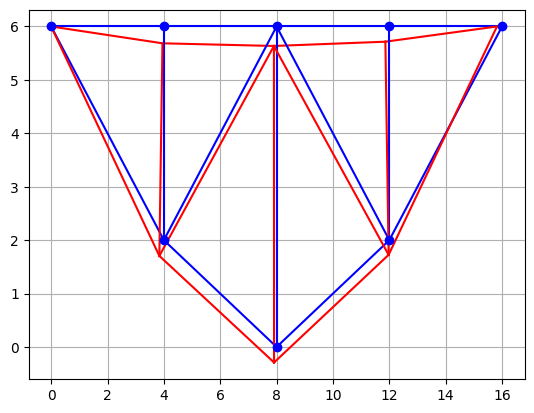

In [29]:
fig = plt.figure()
# fig.gca().set_aspect("equal",adjustable="box")
for e in elements:
    ni = e[0]
    nj = e[1]
    xi = nodes[ni-1][0]
    yi = nodes[ni-1][1]
    uxi = nodes[ni-1][0]+round(nodeDisp(int(ni), 1),5)*500
    uyi = nodes[ni-1][1]+round(nodeDisp(int(ni), 2),5)*500
    xj = nodes[nj-1][0]
    yj = nodes[nj-1][1]
    uxj = nodes[nj-1][0]+round(nodeDisp(int(nj), 1),5)*500
    uyj = nodes[nj-1][1]+round(nodeDisp(int(nj), 2),5)*500
    print("Node ",ni," ",xi," ",yi,"Node ",nj," ",xj," ",yj)
    plt.plot([xi,xj],[yi,yj],'-b')
    plt.plot([uxi,uxj],[uyi,uyj],'-r')
for n in nodes:
    plt.plot(n[0],n[1],'bo')
plt.grid(True)
plt.show()

In [30]:
basicForce(5) #Element force in member 5 (nodes 5-6)

[30052.038200428324]

In [31]:
mbrForces = np.array([])
for i, mbr in enumerate(elements):
    axialForce = round(basicForce(i+1)[0]/1000,2)
    mbrForces = np.append(mbrForces,axialForce) #Store axial loads
    print(f'Force in member {i+1} (nodes {mbr[0]} to {mbr[1]}) is {axialForce} kN')

Force in member 1 (nodes 1 to 2) is -23.75 kN
Force in member 2 (nodes 2 to 3) is -23.75 kN
Force in member 3 (nodes 3 to 4) is -21.25 kN
Force in member 4 (nodes 4 to 5) is -21.25 kN
Force in member 5 (nodes 5 to 6) is 30.05 kN
Force in member 6 (nodes 6 to 7) is 27.95 kN
Force in member 7 (nodes 7 to 8) is 27.95 kN
Force in member 8 (nodes 1 to 8) is 33.59 kN
Force in member 9 (nodes 2 to 8) is -10.0 kN
Force in member 10 (nodes 3 to 8) is -1.77 kN
Force in member 11 (nodes 3 to 7) is -25.0 kN
Force in member 12 (nodes 3 to 6) is -5.3 kN
Force in member 13 (nodes 4 to 6) is -5.0 kN


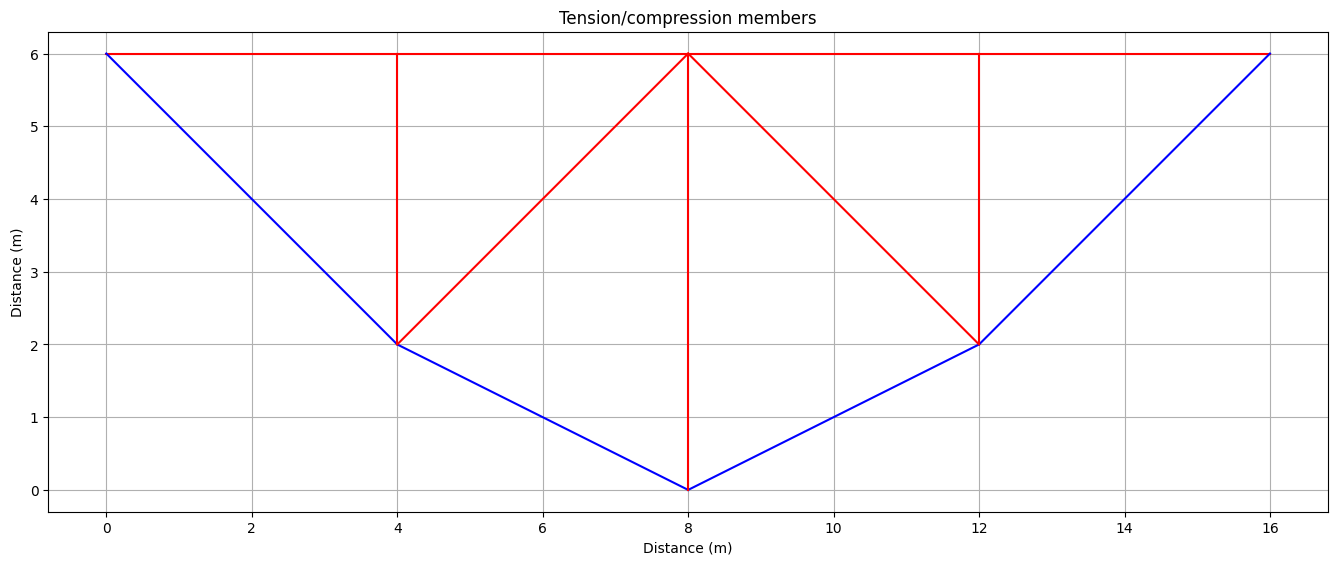

In [32]:
fig = plt.figure()
axes = fig.add_axes([0.1,0.1,2,2])
fig.gca().set_aspect('equal', adjustable='box')

#Plot members
for n, mbr in enumerate(elements):
    node_i = mbr[0] #Node number for node i of this member
    node_j = mbr[1] #Node number for node j of this member

    ix = nodes[node_i-1,0] #x-coord of node i of this member
    iy = nodes[node_i-1,1] #y-coord of node i of this member
    jx = nodes[node_j-1,0] #x-coord of node j of this member
    jy = nodes[node_j-1,1] #y-coord of node j of this member

    if(abs(mbrForces[n])<0.001):
        axes.plot([ix,jx],[iy,jy],'grey',linestyle='--') #Zero force in member
    elif(mbrForces[n]>0):
        axes.plot([ix,jx],[iy,jy],'b') #Member in tension
    else:
        axes.plot([ix,jx],[iy,jy],'r') #Member in compression

axes.set_xlabel('Distance (m)')
axes.set_ylabel('Distance (m)')
axes.set_title('Tension/compression members')
axes.grid()
plt.show()